# Turkey Business Activity - Live Footfall with YOLO

Goal: measure **how much commercial activity** there is at high-footfall locations in Turkey
(Istanbul squares & bazaars, Konya) from public live cameras, and turn it into business intelligence:

- **How much / when** - footfall time series + peak-hour profile.
- **What is an anomaly** - rolling z-score on footfall (crowd surge / unusual drop).
- **Prolonged stops** - dwell-time tracking: a person or vehicle that lingers in front of the camera.
- **Is it worth opening a business here?** - a simple footfall + dwell + consistency score.

Cameras and access methods are documented in `docs/turkey_cameras.md`.

> **Important - the live-data question.** A notebook cell runs **once** and stops, so it can never be a
> truly "live" app. The real answer is to **decouple collection from display** (Section 7): a
> `collector.py` process samples 24/7 into a database, and a separate dashboard reads it and auto-refreshes.
> This notebook is for *prototyping the analysis*; the collector + Streamlit app make it live.

### Network reality

The IBB streams (`livestream.ibb.gov.tr`) are public, but reachable only from an **open network** -
your own machine, a VM, or a deployed app. Restricted sandboxes (incl. the environment that generated
this repo) block those hosts via an allowlist. So **run this notebook locally**, where the streams resolve.

## 0. Setup

In [1]:
%pip install -q ultralytics opencv-python-headless yt-dlp pandas numpy matplotlib firebase-admin

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys, time, datetime as dt
from collections import defaultdict
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make the shared app/ package importable from the notebook
sys.path.append(str(Path.cwd()))
from app.detect_core import load_model, detect_and_count, grab_frame, resolve_youtube, resolve_stream, VEHICLE_NAMES
from app.cameras import CAMERAS, active_cameras, GRID_CAMERAS

DATA_DIR = Path('data'); DATA_DIR.mkdir(exist_ok=True)
model = load_model('yolov8n.pt')
print('cameras available:', list(active_cameras()))
print('dashboard grid (4 live cameras):', GRID_CAMERAS)

cameras available: ['konya_hukumet', 'taksim', 'taksim_yeni', 'beyazit_meydan', 'kapali_carsi', 'misir_carsisi', 'sultanahmet_1', 'sultanahmet_1_yeni', 'kadikoy', 'eyup_sultan', 'uskudar', 'otogar_kavsagi', 'konya_kulturpark', 'konya_millet_caddesi', 'giresun_gazi']
dashboard grid (4 live cameras): ['konya_hukumet', 'otogar_kavsagi', 'sultanahmet_1_yeni', 'taksim_yeni']


## 1. Pick a camera

Verified high-footfall Turkey commercial cameras live in `app/cameras.py`. Grand Bazaar, Spice Bazaar,
Taksim and Kadikoy are the densest commerce. The four cameras the live dashboard shows side by side
(`GRID_CAMERAS`) are **Konya - Hukumet Meydani**, **Giresun - Gazi Caddesi**, **Otogar Kavsagi** and
**Kadikoy**.

`resolve_stream(cam)` turns any catalog entry into an openable HLS URL regardless of `kind`:

- `hls` - used directly (IBB / tvkur).
- `youtube` - resolved via yt-dlp.
- `skyline` - Giresun: the tokenized `hd-auth.skylinewebcams.com` playlist, scraped from the page.
- `webcamera24` - Otogar Kavsagi: the embedded tvkur/YouTube player on the webcamera24 page.

The skyline and webcamera24 hosts only resolve from an **open network** (and rotate their tokens), so
run this on your own machine; in a restricted sandbox they fail like the IBB hosts.

In [3]:
CAM_ID = 'konya_hukumet'   # works from any open network via tvkur. Other grid cams:
                           #   giresun_gazi (skylinewebcams), otogar_kavsagi (webcamera24), kadikoy (IBB)
                           # IBB cameras (taksim/kapali_carsi/...) may be geo-restricted to Turkey IPs.
cam = CAMERAS[CAM_ID]
stream_url = resolve_stream(cam)   # handles hls / youtube / skyline / webcamera24
print(cam['name'], '->', stream_url)

Konya - Hukumet Meydani / Sarraflar Yeralti Carsisi -> https://content.tvkur.com/l/c77i84vbb2nj4i0fr80g/master.m3u8


## 2. Single-frame check

Confirm the stream decodes and YOLO sees the crowd before collecting anything.

frame shape: (1080, 1920, 3)
counts: {'person': 2, 'bicycle': 0, 'car': 4, 'motorcycle': 0, 'bus': 0, 'truck': 0, 'vehicles': 4}


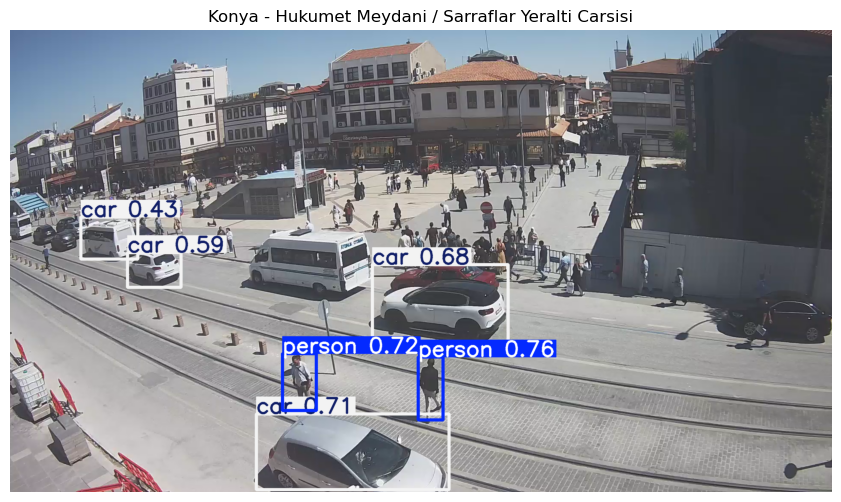

In [4]:
frame = grab_frame(stream_url)
if frame is None:
    print(f"WARN: {cam['name']} returned no frame (likely geo-blocked or stream down).")
    print('Try CAM_ID = \'konya_hukumet\' (tvkur, reachable everywhere) and re-run cell 1.')
else:
    print('frame shape:', frame.shape)
    print('counts:', detect_and_count(model, frame))

    res = model.predict(frame, conf=0.35, classes=[0,1,2,3,5,7], verbose=False)[0]
    plt.figure(figsize=(11, 6))
    plt.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)); plt.axis('off')
    plt.title(cam['name']); plt.show()

## 3. Footfall time series (sparse sampling)

For the **how much / when** question we don't need every frame - one sample every 15-30s is plenty and
is gentle on the server. This is the same logic the collector runs continuously.

In [5]:
def footfall_series(stream_url, cam_name, interval_s=20, duration_min=1.0):
    rows, t_end = [], time.time() + duration_min * 60
    while time.time() < t_end:
        ts = dt.datetime.now(dt.timezone.utc)
        f = grab_frame(stream_url)
        c = detect_and_count(model, f) if f is not None else {'person': np.nan, 'vehicles': np.nan}
        rows.append({'ts': ts, 'cam': cam_name, 'person': c.get('person'), 'vehicles': c.get('vehicles')})
        print(f"[{ts:%H:%M:%S}] person={c.get('person')} vehicles={c.get('vehicles')}")
        time.sleep(interval_s)
    return pd.DataFrame(rows)

# Short live-collection run. Raise duration_min for longer studies, or just leave the
# collector daemon (`python -m app.collector`) running for genuine 24/7 data.
df = footfall_series(stream_url, cam['name'], interval_s=10, duration_min=1.0)
df.to_csv(DATA_DIR / f'footfall_{CAM_ID}.csv', index=False)
df.head()

[12:17:37] person=2 vehicles=4
[12:17:48] person=2 vehicles=4
[12:17:59] person=4 vehicles=5
[12:18:10] person=3 vehicles=6
[12:18:21] person=4 vehicles=9
[12:18:32] person=6 vehicles=7


,ts,cam,person,vehicles
0,2026-06-27 12:17:37.238927+00:00,Konya - Hukumet Meydani / Sarraflar Yeralti Ca...,2,4
1,2026-06-27 12:17:48.202769+00:00,Konya - Hukumet Meydani / Sarraflar Yeralti Ca...,2,4
2,2026-06-27 12:17:59.238455+00:00,Konya - Hukumet Meydani / Sarraflar Yeralti Ca...,4,5
3,2026-06-27 12:18:10.458249+00:00,Konya - Hukumet Meydani / Sarraflar Yeralti Ca...,3,6
4,2026-06-27 12:18:21.460667+00:00,Konya - Hukumet Meydani / Sarraflar Yeralti Ca...,4,9


## 4. Anomalies + peak-hour profile

**Anomaly = rolling z-score > 2.5** on the footfall series: a sudden surge (event/promotion/protest) or an
unusual drop (closure/weather). Peak-hour profile tells you *when* the commercial window is.

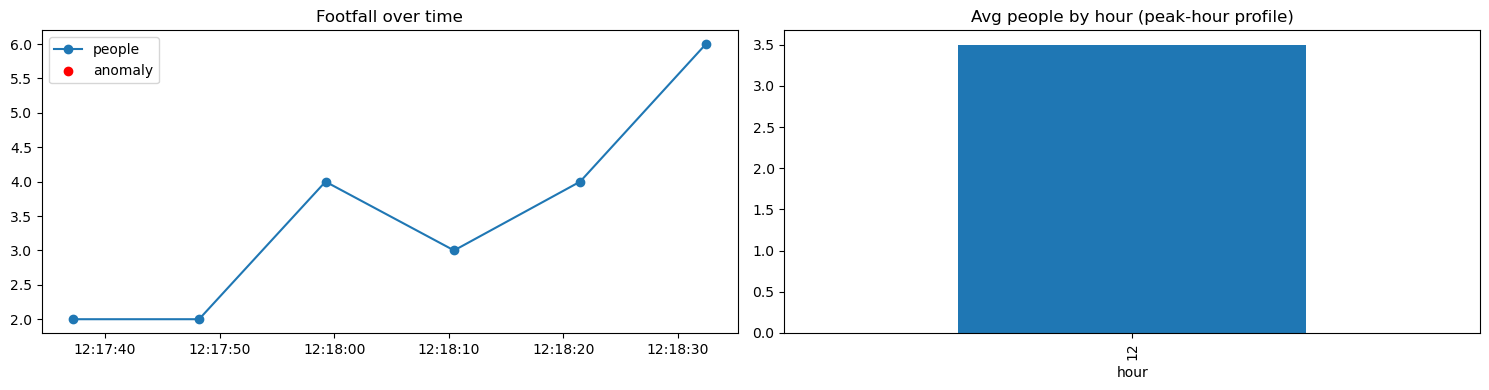

In [6]:
def flag_anomalies(s, window=12, z=2.5):
    mu = s.rolling(window, min_periods=4).mean()
    sd = s.rolling(window, min_periods=4).std().replace(0, np.nan)
    return ((s - mu) / sd).abs() > z

df['ts'] = pd.to_datetime(df['ts'])
df['anomaly'] = flag_anomalies(df['person'])

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(df['ts'], df['person'], marker='o', label='people')
an = df[df['anomaly'] == True]
ax[0].scatter(an['ts'], an['person'], color='red', zorder=5, label='anomaly')
ax[0].set_title('Footfall over time'); ax[0].legend()

df['hour'] = df['ts'].dt.hour
df.groupby('hour')['person'].mean().plot(kind='bar', ax=ax[1])
ax[1].set_title('Avg people by hour (peak-hour profile)')
plt.tight_layout(); plt.show()

## 5. Dwell-time / prolonged stops (tracking)

"How long does a person or vehicle stay in front of the camera?" needs **object tracking** (stable IDs
across frames), which only works on *consecutive* frames - so here we take a short **dense burst**
(a few fps for ~60s) instead of sparse sampling. Ultralytics `model.track()` (ByteTrack) gives each
object an id; we accumulate how many frames each id is seen and how little it moves.

- **Long dwell + low movement** = lingering: window-shopping / a queue / a parked vehicle.
- High share of *lingering* people is a strong **commercial-quality** signal (people stop, not just pass).

In [7]:
from app.detect_core import iter_frames, NAME_BY_ID

def dwell_analysis(stream_url, seconds=30, target_fps=3, conf=0.35):
    """Dense burst with tracking. Returns per-track dwell seconds + movement.

    iter_frames handles header-required hosts (tvkur, IBB, skylinewebcams) by
    downloading the latest segments with the right Referer/Origin and decoding
    locally, since cv2.VideoCapture(url) can't pass headers on Windows.
    """
    frames_seen = defaultdict(int)
    centroids = defaultdict(list)
    track_cls = {}
    n_frames = int(seconds * target_fps)
    for frame in iter_frames(stream_url, max_frames=n_frames):
        r = model.track(frame, persist=True, conf=conf, classes=[0,2,3,5,7],
                        tracker='bytetrack.yaml', verbose=False)[0]
        if r.boxes.id is not None:
            for box, tid, cl in zip(r.boxes.xywh.cpu().numpy(),
                                    r.boxes.id.int().cpu().tolist(),
                                    r.boxes.cls.int().cpu().tolist()):
                frames_seen[tid] += 1
                centroids[tid].append((float(box[0]), float(box[1])))
                track_cls[tid] = cl

    rows = []
    for tid, n in frames_seen.items():
        pts = np.array(centroids[tid])
        movement = float(np.linalg.norm(pts.max(0) - pts.min(0))) if len(pts) > 1 else 0.0
        rows.append({'track_id': tid,
                     'class': NAME_BY_ID.get(track_cls[tid], str(track_cls[tid])),
                     'dwell_s': round(n / target_fps, 1),
                     'movement_px': round(movement, 1)})
    return pd.DataFrame(rows).sort_values('dwell_s', ascending=False) if rows else pd.DataFrame(
        columns=['track_id','class','dwell_s','movement_px'])

dwell = dwell_analysis(stream_url, seconds=30, target_fps=3, conf=0.25)
dwell.head(15)

,track_id,class,dwell_s,movement_px
9,10,car,26.7,19.5
0,1,car,26.3,870.3
3,4,person,26.3,217.1
15,29,person,23.7,24.0
1,2,car,23.3,16.9
14,16,car,23.0,191.6
4,5,person,21.0,155.0
7,8,car,20.7,7.6
13,14,person,15.0,7.3
16,37,person,10.3,36.0


In [8]:
# Flag prolonged stationary objects: long dwell AND little movement.
PERSON_DWELL_S, VEHICLE_DWELL_S, MAX_MOVE_PX = 25, 40, 60
if not dwell.empty:
    is_person = dwell['class'] == 'person'
    stationary = dwell[((is_person & (dwell['dwell_s'] >= PERSON_DWELL_S)) |
                        (~is_person & (dwell['dwell_s'] >= VEHICLE_DWELL_S)))
                       & (dwell['movement_px'] <= MAX_MOVE_PX)]
    print(f"Prolonged stops detected: {len(stationary)}")
    display(stationary)
    linger_rate = (is_person & (dwell['dwell_s'] >= PERSON_DWELL_S)).sum() / max(1, is_person.sum())
    print(f"Linger rate (people who stayed >= {PERSON_DWELL_S}s): {linger_rate:.0%}")

Prolonged stops detected: 0


,track_id,class,dwell_s,movement_px


Linger rate (people who stayed >= 25s): 3%


## 5b. Re-identification - "have I seen this person before?"

The detection counts above tell you *how many* people are visible at any moment, but they
double-count anyone who lingers in front of the camera. To answer questions like *"how many
unique customers walked by today?"* or *"is that the same delivery van I saw yesterday?"*
we need **re-identification**: a persistent identity attached to each person/vehicle that
survives across frames, bursts and days.

The implementation is in `app/reid.py`:

1. For each YOLO detection, crop the bounding box.
2. Build a *masked* HSV color histogram (8x8x8 bins, V<30 pixels ignored - kills the
   sodium-yellow night cast on the Konya square) plus aspect ratio + normalized area.
3. L2-normalize -> 514-dim appearance vector.
4. Compare to every entity of the same class already in `data/reid.db` via cosine
   similarity. If the best match is >= `threshold` (default 0.92) we update its
   `sightings` and `last_seen`; otherwise we register a new entity.

This is a **demo-grade signature**. It works well in daylight (different clothing colors
give clearly different histograms). It produces false matches at night when the whole
scene is yellow-tinted - swap `embed_crop()` for an OSNet/torchreid forward pass for
production-grade re-ID; the SQLite registry around it stays the same.

In [9]:
from app.detect_core import load_model, grab_frame, detect_with_boxes, annotate
from app.reid import ReidStore
import cv2, time
import matplotlib.pyplot as plt

REID_DB = 'data/reid_notebook.db'
Path(REID_DB).parent.mkdir(parents=True, exist_ok=True)

# If we're re-running the notebook (the kernel is alive), the previous ReidStore is
# still holding a SQLite connection to REID_DB. Close it before we try to delete
# the file, otherwise Windows returns PermissionError [WinError 32].
try:
    reid.close()         # noqa: F821  (reid is defined by a prior run of this cell)
except NameError:
    pass

# Fresh registry for the demo so re-runs are reproducible. If something else
# still holds the file (orphan kernel, antivirus scan), we keep the existing
# rows instead of crashing - re-identification just continues with what's there.
try:
    Path(REID_DB).unlink(missing_ok=True)
    print('reid_notebook.db cleared - fresh demo registry')
except PermissionError:
    print('reid_notebook.db is locked by another process - keeping existing rows. '
          'New entities will be merged into the existing registry; this is fine '
          'for the demo, just not a clean-room run.')

reid = ReidStore(REID_DB, threshold=0.92)

# Use the model we already loaded above; lower conf so we catch the small/distant
# people the Konya wide-angle camera shows.
CAM_ID = 'konya_hukumet'
cam = CAMERAS[CAM_ID]
stream_url = cam['url']
print('feeding re-ID from', cam['name'])

reid_notebook.db cleared - fresh demo registry
feeding re-ID from Konya - Hukumet Meydani / Sarraflar Yeralti Carsisi


In [10]:
# Sample N frames every `interval_s` seconds, run YOLO on each, push every detection
# through the re-ID registry. Short loop here so the notebook completes; the collector
# daemon does the real long-running version.
N_SAMPLES, INTERVAL_S, CONF = 8, 5, 0.25

rows = []
for i in range(N_SAMPLES):
    f = grab_frame(stream_url)
    if f is None:
        print(f'[{i:02d}] miss'); time.sleep(INTERVAL_S); continue
    counts, boxes = detect_with_boxes(model, f, conf=CONF)
    results = reid.update_from_frame(CAM_ID, f, boxes)
    new = sum(r.is_new for r in results)
    seen_again = len(results) - new
    rows.append({'sample': i, 'person': counts['person'], 'vehicles': counts['vehicles'],
                 'detections': len(boxes), 'new_ids': new, 'seen_again': seen_again})
    print(f'[{i:02d}] person={counts["person"]} vehicles={counts["vehicles"]} '
          f'-> new={new} seen_again={seen_again}')
    time.sleep(INTERVAL_S)

reid_df = pd.DataFrame(rows)
reid_df

[00] person=0 vehicles=3 -> new=3 seen_again=0
[01] person=0 vehicles=4 -> new=2 seen_again=2
[02] person=0 vehicles=4 -> new=2 seen_again=2
[03] person=0 vehicles=4 -> new=2 seen_again=2
[04] person=0 vehicles=4 -> new=2 seen_again=2
[05] person=0 vehicles=2 -> new=2 seen_again=0
[06] person=0 vehicles=2 -> new=0 seen_again=2
[07] person=0 vehicles=2 -> new=1 seen_again=1


,sample,person,vehicles,detections,new_ids,seen_again
0,0,0,3,3,3,0
1,1,0,4,4,2,2
2,2,0,4,4,2,2
3,3,0,4,4,2,2
4,4,0,4,4,2,2
5,5,0,2,2,2,0
6,6,0,2,2,0,2
7,7,0,2,2,1,1


In [11]:
# Roll-up: how many unique entities did we see? how many came back >=3 times?
stats = reid.stats(CAM_ID)
print('Total unique entities (this camera):', stats['total_unique'])
print('Total sightings:', stats['total_sightings'])
for cls, s in stats['per_class'].items():
    print(f"  {cls:10s}  unique={s['unique']}  sightings={s['total_sightings']}  "
          f"regulars(>=3)={s['regulars']}")

print('\nTop returning entities:')
for r in reid.top_regulars(CAM_ID, n=10):
    print(f"  #{r['entity_id']:4d}  {r['cls']:8s}  sightings={r['sightings']}  "
          f"first={r['first_seen']}  last={r['last_seen']}")

Total unique entities (this camera): 14
Total sightings: 25
  car         unique=14  sightings=25  regulars(>=3)=2

Top returning entities:
  #   3  car       sightings=6  first=2026-06-27T12:18:57Z  last=2026-06-27T12:19:33Z
  #   1  car       sightings=4  first=2026-06-27T12:18:57Z  last=2026-06-27T12:19:15Z
  #   8  car       sightings=2  first=2026-06-27T12:19:15Z  last=2026-06-27T12:19:21Z
  #  11  car       sightings=2  first=2026-06-27T12:19:21Z  last=2026-06-27T12:19:39Z
  #  13  car       sightings=2  first=2026-06-27T12:19:27Z  last=2026-06-27T12:19:33Z
  #   2  car       sightings=1  first=2026-06-27T12:18:57Z  last=2026-06-27T12:18:57Z
  #   4  car       sightings=1  first=2026-06-27T12:19:03Z  last=2026-06-27T12:19:03Z
  #   5  car       sightings=1  first=2026-06-27T12:19:03Z  last=2026-06-27T12:19:03Z
  #   6  car       sightings=1  first=2026-06-27T12:19:09Z  last=2026-06-27T12:19:09Z
  #   7  car       sightings=1  first=2026-06-27T12:19:09Z  last=2026-06-27T12:19:09Z


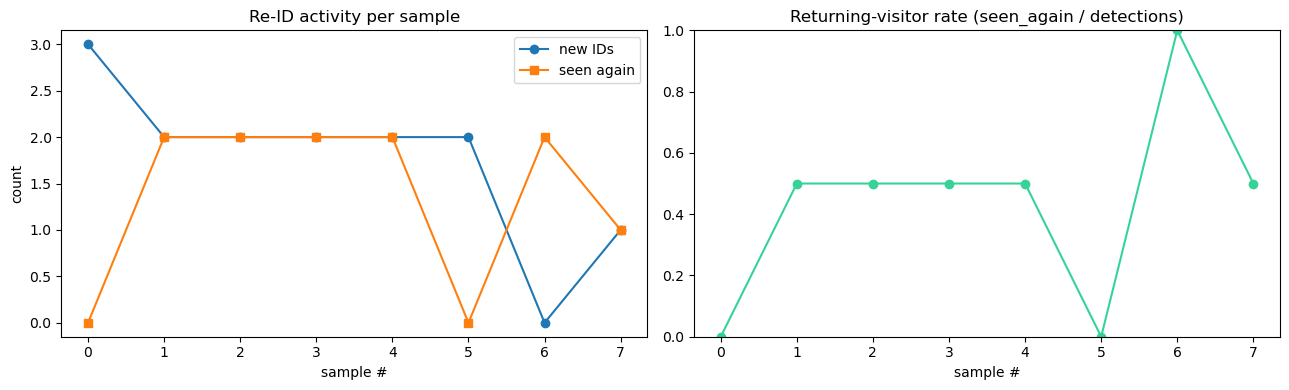

In [12]:
# Visual: returning-visitor curve - what fraction of detections are 'seen again' over time?
if len(reid_df) >= 3:
    reid_df = reid_df.copy()
    reid_df['returning_rate'] = (reid_df['seen_again'] /
                                 reid_df['detections'].replace(0, np.nan))
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(reid_df['sample'], reid_df['new_ids'], marker='o', label='new IDs')
    ax[0].plot(reid_df['sample'], reid_df['seen_again'], marker='s', label='seen again')
    ax[0].set_title('Re-ID activity per sample')
    ax[0].set_xlabel('sample #'); ax[0].set_ylabel('count'); ax[0].legend()

    ax[1].plot(reid_df['sample'], reid_df['returning_rate'].fillna(0), marker='o',
               color='#36d399')
    ax[1].set_title('Returning-visitor rate (seen_again / detections)')
    ax[1].set_xlabel('sample #'); ax[1].set_ylim(0, 1)
    plt.tight_layout(); plt.show()
else:
    print('Not enough samples for the returning-visitor plot.')

IMPORTANT - re-ID quality depends on the scene.
#
At Konya Hukumet Meydani at night the whole scene is uniform sodium yellow.
Color-histogram re-ID will over-merge IDs there. To validate the *concept*, point
the camera at the daylight Grand Bazaar / Spice Bazaar (different clothing colors)
or set `threshold=0.97` to be very conservative about matches.
#
Production path:
  pip install torchreid
  from torchreid.utils import FeatureExtractor
  extractor = FeatureExtractor(model_name='osnet_ain_x1_0', model_path='', device='cpu')
  def embed_crop(crop, cls): return extractor([crop])[0].cpu().numpy()
Then keep the rest of app/reid.py exactly as-is. The 2,048-dim OSNet embedding
survives lighting changes, pose changes, and partial occlusion much better than
a color histogram.

## 6. "Is it worth opening a business here?" - a simple score

Combine three signals into one 0-100 score. Tune the weights to your business type (a cafe wants high
*linger*; a kiosk wants high *throughput*).

- **Volume** - median footfall (raw demand).
- **Linger** - share of people who stop (engagement / conversion potential).
- **Consistency** - low coefficient of variation (steady traffic beats spiky).

In [13]:
def business_score(footfall_df, dwell_df, w=(0.5, 0.3, 0.2)):
    people = footfall_df['person'].dropna()
    volume = float(people.median()) if len(people) else 0.0
    cv = float(people.std() / people.mean()) if people.mean() else 1.0
    consistency = max(0.0, 1 - cv)
    is_p = dwell_df['class'] == 'person'
    linger = float((is_p & (dwell_df['dwell_s'] >= 25)).sum() / max(1, is_p.sum())) if len(dwell_df) else 0.0
    vol_norm = min(1.0, volume / 40.0)  # ~40 people/frame treated as 'very busy'; tune per camera FOV
    score = 100 * (w[0]*vol_norm + w[1]*linger + w[2]*consistency)
    return {'volume_median': round(volume,1), 'linger_rate': round(linger,2),
            'consistency': round(consistency,2), 'score_0_100': round(score,1)}

print(cam['name'])
business_score(df, dwell)

Konya - Hukumet Meydani / Sarraflar Yeralti Carsisi


{'volume_median': 3.5,
 'linger_rate': 0.03,
 'consistency': 0.57,
 'score_0_100': 16.6}

## 7. Making it LIVE - collector + dashboard (the real answer)

Everything above is a **one-shot** measurement: the cell runs, then stops. To get an app whose numbers
keep updating, you split the system into two long-lived processes that share a database:

```
  live streams ─►  [ collector loop ]  ─►  Cloud Firestore  ─►  [ web/index.html ]  ─►  you
                   samples every Ns       3 collections          subscribes via onSnapshot
                   YOLO + re-ID           footfall / latest /    (no polling, no refresh)
                                          reid_stats
```

**1) Run the collector from this notebook (cell below).** It is the same code as
`python -m app.collector` - same `sample_once`, same `FirebaseStore`, same `ReidStore` -
just driven from a notebook loop so you stay in Jupyter. Interrupt with the kernel's
■ Stop button to end cleanly.

Prerequisites (one-time):

- `pip install firebase-admin` (already in `requirements.txt`).
- Set `FIREBASE_CREDENTIALS` to the absolute path of your service-account JSON
  *before* you launch Jupyter - `os.environ['FIREBASE_CREDENTIALS'] = ...` set
  inside the notebook also works, see the cell below.

**2) Serve the live HTML dashboard (separate terminal):**
```bash
python serve.py                           # opens http://localhost:8000 automatically
```
That's the one-shot launcher from the project root - it serves `web/` with no-cache
headers, picks a free port if 8000 is busy, and warns if `web/firebase-config.js`
is missing. The dashboard subscribes to Firestore from the browser; every write the
notebook loop makes shows up on the page within a second.

For long-running production use, run the collector under `nohup` / `systemd` / Docker
so it survives shell exits and reboots; the notebook loop is the convenient way to
develop, demo, and inspect the same pipeline interactively.

In [ ]:
# Run the live dashboard + collector from this single notebook cell.
#
# What this cell does, in order:
#   1. Self-heals firebase-admin if missing in this kernel.
#   2. Starts a THREADED HTTP server in a background daemon thread serving web/
#      on http://localhost:8000, with the tvkur HLS proxy mounted so the Konya
#      tiles autoplay without their click-to-play splash. Threaded matters:
#      4 cameras x (chunklist + segments) = many concurrent requests; a
#      single-threaded server queues them and the video stalls on "loading...".
#      Idempotent across cell re-runs.
#   3. Opens the dashboard in your browser AND embeds it inline below.
#   4. Runs the collector loop for DURATION_MIN minutes (default 5), detecting
#      anomalies + returning visitors and saving snapshots under web/snapshots/
#      which the dashboard reads back as thumbnails.
#
# To extend the run, just press Run on this cell again - the dashboard server
# stays up between runs, and a new 5-minute collector window begins.
# Press the ■ Stop button to end the collector early; the dashboard server
# keeps serving so you can still browse the data already in Firestore.

import os, sys, time, subprocess, threading, webbrowser, http.server
import datetime as dt
from pathlib import Path

# ---- 0. Self-heal firebase-admin in this kernel ----------------------------
try:
    import firebase_admin  # noqa: F401
except ModuleNotFoundError:
    print('firebase-admin not in this kernel - installing now...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'firebase-admin'])
    import firebase_admin  # noqa: F401
    print('firebase-admin installed.')

from app.collector        import sample_once, AnomalyTracker
from app.firebase_store   import FirebaseStore
from app.reid             import ReidStore
from app.dashboard_server import DashboardHandler, WEB_DIR, port_is_free
# `model`, `CAMERAS`, `active_cameras` and `Path` were brought in by Section 0.

# ---- 1. Knobs --------------------------------------------------------------
# Must mirror GRID_CAMERAS in app/cameras.py and web/cameras.js so every
# dashboard tile receives data.
LIVE_CAMS      = ['konya_hukumet', 'otogar_kavsagi',
                  'sultanahmet_1_yeni', 'taksim_yeni']   # 4 dashboard tiles
INTERVAL_S     = 20      # seconds between sampling rounds
CONF           = 0.30    # YOLO confidence threshold
DURATION_MIN   = 5       # bounded run; re-run the cell to continue
DASHBOARD_PORT = 8000

if not os.environ.get('FIREBASE_CREDENTIALS'):
    os.environ['FIREBASE_CREDENTIALS'] = str(Path.cwd() /
        'turkey-footfall-firebase-adminsdk-fbsvc-249068706b.json')

# ---- 2. Background dashboard server (idempotent across re-runs) ------------
# Uses the SHARED DashboardHandler so the /tvkur/ HLS proxy is active here too
# (otherwise the Konya tiles can't autoplay - content.tvkur.com refuses bare
# requests and sends no CORS headers). ThreadingHTTPServer is critical: the
# four hls.js instances pull chunklists + segments in parallel, and a single
# thread would serialize them into a stall. Stash the server on the kernel's
# __main__ module so re-running the cell does NOT try to rebind the port.
_main = sys.modules['__main__']

if getattr(_main, '_dash_server', None) is None:
    if not port_is_free(DASHBOARD_PORT):
        print(f'Port {DASHBOARD_PORT} already in use - assuming serve.py is up. '
              f'Dashboard: http://localhost:{DASHBOARD_PORT}/')
        _main._dash_server = 'external'
    else:
        handler_factory = lambda *a, **k: DashboardHandler(*a, directory=str(WEB_DIR), **k)
        http.server.ThreadingHTTPServer.allow_reuse_address = True
        http.server.ThreadingHTTPServer.daemon_threads      = True
        srv = http.server.ThreadingHTTPServer(('', DASHBOARD_PORT), handler_factory)
        threading.Thread(target=srv.serve_forever, daemon=True).start()
        _main._dash_server = srv
        print(f'Dashboard server (threaded + tvkur proxy) started -> '
              f'http://localhost:{DASHBOARD_PORT}/')
else:
    print(f'Dashboard server already running -> http://localhost:{DASHBOARD_PORT}/')

if not (WEB_DIR / 'firebase-config.js').is_file():
    print('  ! web/firebase-config.js missing - the page will show a config-warning '
          'banner until you create it (cp web/firebase-config.example.js web/firebase-config.js).')

# ---- 3. Open the browser + inline preview ---------------------------------
dash_url = f'http://localhost:{DASHBOARD_PORT}/'
if not getattr(_main, '_dash_browser_opened', False):
    try:
        webbrowser.open(dash_url, new=2)
    except Exception as e:
        print(f'  ! could not auto-open the browser ({e}); open {dash_url} yourself.')
    _main._dash_browser_opened = True

try:
    from IPython.display import display, HTML, IFrame
    display(HTML(
        f'<p style="margin:4px 0"><b>Live dashboard:</b> '
        f'<a href="{dash_url}" target="_blank">{dash_url}</a> '
        f'(also opened in a new browser tab)</p>'
    ))
    display(IFrame(dash_url, width='100%', height=560))
except Exception:
    pass  # IPython not available (rare) - the browser tab + URL are enough.

# ---- 4. Bounded collector loop --------------------------------------------
# AnomalyTracker survives across cell re-runs so the rolling window keeps
# accumulating (a fresh window every 5 min would never trip the z-score).
firebase  = FirebaseStore()
reid_live = ReidStore('data/reid.db', threshold=0.92)
if getattr(_main, '_anomaly_tracker', None) is None:
    _main._anomaly_tracker = AnomalyTracker()
anomaly = _main._anomaly_tracker

print(f'\nCollector: {len(LIVE_CAMS)} camera(s) for {DURATION_MIN} min, '
      f'interval={INTERVAL_S}s, conf={CONF}')
print('Anomaly + returning-visitor snapshots save under web/snapshots/.')
print(f'Re-run this cell to continue for another {DURATION_MIN} minutes.\n')

end_at = time.time() + DURATION_MIN * 60
cycles = 0
try:
    while time.time() < end_at:
        round_start = time.time()
        cycles += 1
        for cam_id in LIVE_CAMS:
            cam = CAMERAS.get(cam_id)
            if not cam:
                print(f'  skip {cam_id}: not in catalog'); continue
            sample_once(model, cam_id, cam, firebase, reid=reid_live, conf=CONF,
                        anomaly=anomaly, save_snapshots=True)
        remaining = int(end_at - time.time())
        print(f'  -- cycle {cycles} done, {remaining}s remaining --')
        time.sleep(max(0, INTERVAL_S - (time.time() - round_start)))
    print(f'\n{DURATION_MIN}-minute window finished cleanly. '
          f'{cycles} cycles written. Re-run the cell to continue.')
except KeyboardInterrupt:
    print(f'\nStopped early after {cycles} cycle(s). '
          f'Dashboard server stays up at {dash_url}.')
finally:
    reid_live.close()

Dashboard server (threaded + tvkur proxy) started -> http://localhost:8000/


  "GET / HTTP/1.1" 200 -
  "GET /firebase-config.js?v=13 HTTP/1.1" 200 -
  "GET /app.js?v=13 HTTP/1.1" 200 -
  "GET /cameras.js?v=13 HTTP/1.1" 200 -

Collector: 4 camera(s) for 5 min, interval=20s, conf=0.3
Anomaly + returning-visitor snapshots save under web/snapshots/.
Re-run this cell to continue for another 5 minutes.

  "GET /tvkur/c77i84vbb2nj4i0fr80g/master.m3u8 HTTP/1.1" 200 -
  "GET /tvkur/c77i91vbb2nj4i0fr81g/master.m3u8 HTTP/1.1" 200 -
  "GET / HTTP/1.1" 200 -
  "GET /firebase-config.js?v=13 HTTP/1.1" 200 -
  "GET /cameras.js?v=13 HTTP/1.1" 200 -
  "GET /app.js?v=13 HTTP/1.1" 200 -
  "GET /snapshots/anomalies/konya_hukumet/20260627_115942_annotated.jpg HTTP/1.1" 200 -
  "GET /tvkur/c77i84vbb2nj4i0fr80g/master.m3u8 HTTP/1.1" 200 -
  "GET /tvkur/c77i91vbb2nj4i0fr81g/master.m3u8 HTTP/1.1" 200 -
  "GET /tvkur/c77i84vbb2nj4i0fr80g/19212-1782562784.ts HTTP/1.1" 200 -
  "GET /tvkur/c77i91vbb2nj4i0fr81g/16696-1782562785.ts HTTP/1.1" 200 -
[2026-06-27T12:19:48.120821+00:00] konya_huk

## 8. Compare multiple commercial sites

Loop the footfall sampler over several cameras to rank locations by activity - the input to a
site-selection decision.

In [ ]:
# Rank the four dashboard cameras (plus the bazaars) by activity. Each camera is
# tested briefly; cameras that can't be resolved or return no frames are skipped.
seen = set(); SITES = []
for cid in GRID_CAMERAS + ['kapali_carsi', 'misir_carsisi']:
    if cid not in seen:
        seen.add(cid); SITES.append(cid)

summary = []
for cid in SITES:
    c = CAMERAS.get(cid)
    if not c or not c.get('url'):
        print(f'{cid}: skipped (not in catalog or no url)')
        continue
    try:
        url = resolve_stream(c)
    except Exception as e:
        print(f'{cid}: resolve failed ({e})')
        continue
    # one quick decode check before spending 30s on this camera
    if grab_frame(url) is None:
        print(f'{cid}: no frame from stream (geo-blocked / down). Skipping.')
        continue
    sdf = footfall_series(url, c['name'], interval_s=10, duration_min=0.5)
    summary.append({'site': c['name'],
                    'median_people': sdf['person'].median(),
                    'max_people': sdf['person'].max()})

pd.DataFrame(summary).sort_values('median_people', ascending=False)

## 9. Live summary - what did we find?

Pulls everything the notebook saw on this run into a single block: the anomalies
flagged across every sampled camera, the re-ID totals, and a tiny visualisation
plotting all anomalies on the same timeline. Re-running the notebook regenerates
this from scratch - no stale timestamps from someone else's session leak through.

In [ ]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    from datetime import datetime, timezone

    print(f"Notebook run finished at {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')} UTC")
    print(f"Live camera for this run: {cam['name']}")
    print("=" * 78)

    # ---- aggregate anomalies into one DataFrame ----
    anom_frames = []
    if "df" in dir() and isinstance(df, pd.DataFrame) and not df.empty and "anomaly" in df.columns:
        a = df[df["anomaly"] == True].copy()
        if not a.empty:
            a["cam"] = cam["name"]
            anom_frames.append(a[["ts", "cam", "person", "vehicles"]])
    anom = pd.concat(anom_frames, ignore_index=True) if anom_frames else \
           pd.DataFrame(columns=["ts", "cam", "person", "vehicles"])

    if len(anom):
        print(f"\nAnomalies flagged (rolling z > 2.5): {len(anom)}")
        print(anom.to_string(index=False))
    else:
        print("\nAnomalies flagged: 0")
        print("(Too few samples for the z-score window to trip, or the scene was steady.)")

    # ---- re-ID rollup ----
    if "reid" in dir():
        stats = reid.stats(CAM_ID)
        print("\n" + "-" * 78)
        print(f"Re-identification - {cam['name']}")
        print(f"  total unique entities   : {stats['total_unique']}")
        print(f"  total sightings         : {stats['total_sightings']}")
        for cls, s in stats["per_class"].items():
            print(f"    {cls:10s}  unique={s['unique']}  "
                  f"sightings={s['total_sightings']}  "
                  f"regulars(>=3)={s['regulars']}")
        regulars = reid.top_regulars(CAM_ID, n=5)
        if regulars:
            print("  top returning:")
            for r in regulars:
                print(f"    #{r['entity_id']:>4}  {r['cls']:8s}  "
                      f"sightings={r['sightings']}  last_seen={r['last_seen']}")

    # ---- always-on visual: footfall over this run + anomalies overlaid ----
    # Build the plot only when we have data; do NOT call ax.legend() on an empty
    # axes (that produces the "No artists with labels found" warning).
    if "df" in dir() and isinstance(df, pd.DataFrame) and not df.empty:
        ts = pd.to_datetime(df["ts"])
        fig, ax = plt.subplots(figsize=(12, 3.5))
        ax.plot(ts, df["person"],   marker="o", color="#4f8cff", label="people")
        ax.plot(ts, df["vehicles"], marker="s", color="#f0a35e", label="vehicles", alpha=0.85)
        if len(anom):
            ax.scatter(pd.to_datetime(anom["ts"]), anom["person"],
                       s=160, color="#ef4444", marker="X", zorder=5, label="anomaly")
        ax.set_title(f"This run: {cam['name']}  ({len(df)} samples, {len(anom)} anomalies)")
        ax.set_ylabel("count per frame"); ax.set_xlabel("timestamp (UTC)")
        ax.legend(loc="upper left"); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    print("\n" + "=" * 78)
    print("For the persistent shared HTML dashboard (Firestore-backed):")
    print("  collector  : run the cell in Section 7 of this notebook,")
    print("               or `python -m app.collector --interval 20 --only "
          "konya_hukumet,otogar_kavsagi,konya_kulturpark,konya_millet_caddesi`")
    print("  dashboard  : python serve.py        (from the project root)")
    print("  open       : http://localhost:8000  (opens automatically)")

except Exception as e:
    print(f"summary cell stopped early: {type(e).__name__}: {e}")
